# La prueba de Wilcoxon de una muestra (parte 2)

En este ejemplo práctico aplicaremos la prueba de los rangos con signo de Wilcoxon a este problema en particular:

> Supongamos que somos científicos de datos y desplegamos un nuevo modelo de Machine Learning que supuestamente genera predicciones más rápido que el anterior. El modelo anterior tiene una mediana de inferencia de 200 ms y queremos **determinar si el nuevo modelo tiene un menor tiempo de inferencia**

Y veremos cómo implementar todos los pasos para llevar a cabo esta prueba (muy similares a los pasos que llevamos a cabo en las pruebas paramétricas del curso anterior).

## 1. Desarrollo de la prueba de hipótesis

Es una prueba **unilateral** (pues queremos determinar si el tiempo de inferencia es menor).

### 1.1. Paso 1: definir el problema del negocio

> **Queremos tener un modelo más eficiente que tenga un tiempo de respuesta más rápido**

### 1.2. Paso 2: redactar el problema del negocio como un problema de Ciencia de Datos/Machine Learning

> **¿El nuevo modelo tiene un tiempo de respuesta menor, desde el punto de vista estadístico, que el del modelo original?**

### 1.3. Paso 3: definir $H_0$ y $H_1$

- $H_0$: la **mediana** del tiempo de inferencia del nuevo modelo ($\theta$) es igual a la del modelo de referencia ($\theta_0 = 200 \text{ms}$) $\rightarrow \theta = 200 \text{ms}$
- $H_1$: la **mediana** del tiempo de inferencia del nuevo modelo es **menor** que la del modelo de referencia $\rightarrow \theta < 200 \text{ms}$

### 1.4. Paso 4: definir $\alpha$

Asumiremos un nivel de significancia $\alpha = 0.05$ y recordemos que la prueba es **unilateral**.

### 1.5. Definir la potencia de la prueba ($1-\beta$) y el tamaño de la muestra ($n$)

Acá viene un elemento contradictorio:

- La prueba de Wilcoxon es **no paramétrica**
- Así que **en principio no existe una fórmula matemática que nos permita estimar estos números en la prueba**
- Sin embargo **podemos usar aproximaciones a partir de las distribuciones Z y t** para estimar la potencia y el tamaño de la muestra.

Y estas aproximaciones son válidas porque:

> Los valores de la estadística *W* siguen una distribución quasi-normal

Veamos cómo diseñar la prueba teniendo en cuenta lo anterior.

### 1.5.1. Definir el tamaño del efecto deseado

Recordemos que:

- $p < \alpha$ nos indica si existen diferencias desde el punto de vista estadístico
- Pero este valor no nos indica qué tan grandes son las diferencias
- El tamaño del efecto nos indica qué tan grandes son las diferencias

Más adelante veremos cómo se calcula el tamaño del efecto una vez hayamos recolectado datos y realizado la prueba.

En el caso de Wilcoxon se define el tamaño del efecto como la **correlación biserial de rango** (*rank-biserial correlation* o *RBC*) que mide la diferencia entre la proporción de rangos positivos ($W^+$) y la proporción de rangos negativos ($W^-$):

$$\text{RBC} = \frac{W^+-W^-}{W^++W^-}$$

Algunas características:
- Está entre -1.0 y 1.0
- 0.0: no hay efecto (los rangos están perfectamente balanceados)
- 1.0 o -1.0: dominancia total (todos los datos están o de un lado o del otro de la mediana)

Y los rangos más usuales son:

- $\text{RBC} \geq 0.1$: efecto "pequeño"
- $\text{RBC} \geq 0.3$: efecto "mediano"
- $\text{RBC} \geq > 0.5$: efecto "grande"

Así que buscaremos obtener un efecto "mediano-grande" $\rightarrow RBC = 0.4$ (tras aplicar la prueba veremos si existe o no un efecto)

**Nota importante:**

Como usaremos más adelante el código Python para la prueba t, la equivalencia entre el $RBC$ de la prueba Wilcoxon y el $d$ de la prueba t es:

$$d = \frac{2\text{RBC}}{\sqrt{1-\text{RBC}^2}}$$

### 1.5.2. Definir la potencia de la prueba

Recordemos que esta potencia es la capacidad que tiene nuestro estudio de detectar un efecto (una diferencia) cuando ese efecto realmente existe.

En nuestro caso es la capacidad que tendrá la prueba de Wilcoxon de detectar que el nuevo modelo tiene un tiempo de inferencia menor que el modelo antiguo, cuando realmente este tiempo de inferencia es menor.

Asumiremos una potencia de 0.9

### 1.5.3. Aproximación: estimación del tamaño de la muestra

Acá viene una primera aproximación ¿cómo estimar el tamaño de la muestra (n) a partir del tamaño del efecto y de la potencia de la prueba?

> Para estimar el tamaño de la muestra en la prueba Wilcoxon usaremos como referencia la distribución t

¿Por qué?

- Porque en esta prueba no paramétrica no se requiere que **los datos** sigan una distribución en particular
- Sin embargo, la estadística *W* de esta prueba **sí sigue una distribución t**

Así que podremos usar este segundo elemento para estimar la potencia de la prueba.

De hecho, se puede demostrar matemáticamente para que la prueba de Wilcoxon y el t-test alcancen la misma potencia el número de datos requerido satisface esta relación:

$$\frac{n_{\text{Wilcoxon}}}{n_{\text{t-test}}} \approx 0.955$$

Entonces el paso a paso para estimar el tamaño de la muestra sería:

1. Estimar $n_{\text{t-test}}$ el tamaño de la muestra como si fuese la prueba t
2. Estimar $n_{\text{Wilcoxon}}$ simplemente como $\frac{n_{\text{t-test}}}{0.955}$

El paso (1) ya lo implementamos en el curso anterior, así que veamos cómo estimar el tamaño de la muestra para esta prueba de Wilcoxon:

In [1]:
import math
from statsmodels.stats.power import TTestPower

rbc = 0.4 # Tamaño del efecto esperado (definido por nosotros)
potencia = 0.9 # Potencia de la prueba esperada (definida por nosotros)
alpha = 0.05 # Nivel de significancia (definido por nosotros)

# 1. Estimar n-ttest
d_cohen = (2 * rbc) / math.sqrt(1 - rbc**2) # Aproximación al d de Cohen
analisis = TTestPower()
nttest = analisis.solve_power(
    effect_size = d_cohen,
    power = potencia,
    alpha = alpha,
    alternative = 'smaller', # "larger", "two-sided" Porque es una prueba unilateral (y menor que)
)

# 2. Estimar n-wilcoxon
n = math.ceil(nttest[0] / 0.955)

print(f"Efecto Cohen's d equivalente: {d_cohen:.2f}")
print(f"Tamaño de la muestra T-test: {math.ceil(nttest[0])}")
print(f"Tamaño de la muestra Wilcoxon: {n}")

Efecto Cohen's d equivalente: 0.87
Tamaño de la muestra T-test: 10
Tamaño de la muestra Wilcoxon: 11


/home/jair/BITS/No_parametrica/.venv/lib/python3.11/site-packages/statsmodels/stats/power.py:524: ConvergenceWarning: 
Failed to converge on a solution.

  warnings.warn(convergence_doc, ConvergenceWarning)


Es decir que necesitamos al menos 11 datos para poder estimar el tamaño del efecto esperado (si es que existe) y la potencia.

### 1.6. Paso 6: recolectar y preparar los datos

Supondremos que hemos recolectado $n=85$ datos correspondientes al tiempo de inferencia del modelo:

In [2]:
import pandas as pd

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/46-2026-04-EstadisticaInferencialNoParametrica/data/'

datos = pd.read_csv(RUTA + 'dataset_wilcoxon_una_muestra_unilateral.csv')
datos

,t_inferencia
0,194.7
1,212.0
2,205.5
3,201.5
4,188.2
...,...
80,209.4
81,202.2
82,193.4
83,185.4


Veamos la mediana y la distribución de estos datos:

t_inferencia    196.5
dtype: float64


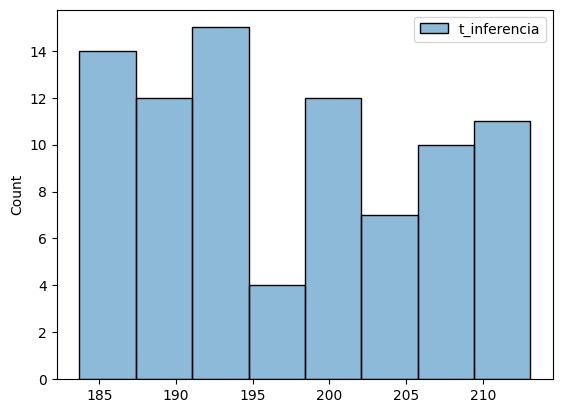

In [3]:
import seaborn as sns

print(datos.median())
sns.histplot(datos);

Al parecer no es una distribución normal. Podemos verificar esto aplicando la [prueba de Shapiro](https://codificandobits.com/curso/estadistica-inferencial-parametrica/2-pruebas-de-normalidad/) (lección 2 del curso Estadística Inferencial Paramétrica):

In [4]:
from scipy.stats import shapiro

W, p_shapiro = shapiro(datos['t_inferencia'])
p_shapiro

0.00022113835375868902

Y vemos que p < 0.05, con lo cual confirmamos que no es una distribución normal y esto nos permite aplicar la prueba de Wilcoxon.

### 1.7. Paso 7: aplicar la prueba estadística para obtener el valor p

Al igual que con las pruebas paramétricas, podemos usar Scipy o pingouin de Python para estimar tanto la estadística como el valor p a partir de los datos.

Veamos cómo hacerlo en Scipy:

In [5]:
from scipy import stats

valor_referencia = 200
W, p = stats.wilcoxon(datos['t_inferencia'] - valor_referencia, alternative='less')

print('Resultado con Scipy:')
print(f"W: {W}, valor p: {p}")

Resultado con Scipy:
W: 1254.0, valor p: 0.0059854437675344475


Vemos que el argumento presentado a esta función es **la diferencia entre las observaciones y el valor de referencia**.

Además, es clave que indiquemos que la alternativa es "less" para intentar determinar si la mediana de las observaciones está **por debajo** del valor de referencia (las otras dos opciones son "greater" or "two-sided").

Como p<0.05, esto nos indica que hay evidencia suficiente para **rechazar** la hipótesis nula y por tanto podemos decir que **el tiempo de inferencia del nuevo modelo es estadísticamente menor que el del modelo antiguo**.

Veamos cómo hacer lo mismo pero con pingouin:

In [6]:
import pingouin as pg

pg.wilcoxon(datos['t_inferencia'] - valor_referencia, alternative="less")

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,1254.0,less,0.006023,-0.313817,NaN


En este caso:

- RBC (rank biserial correlation) es de -0.31:
    - Es negativo por que tenemos más rangos por debajo de 200 que por encima
    - Y como su magnitud es 0.3 podemos decir que el tamaño del efecto es mediano (no lo podemos ignorar)
    
- CLES (*common language effect size*): 
    - "Si tomamos un dato aleatorio del grupo A y otro del grupo B, ¿cuál es la probabilidad de que A > B?"
    - En este caso el resultado es NaN porque no estamos comparando grupos.

### 1.8. Paso 8: aceptar o rechazar $H_0$


Como p < 0.05 rechazamos la hipótesis nula y nos inclinamos por $H_1$ (medias diferentes).

Y por tanto:

> El nuevo modelo tiene un tiempo de inferencia inferior al modelo anterior (mediana de 196.5 ms vs. 200 ms).

### 1.9. Paso 9: evaluar el tamaño del efecto y la potencia de la prueba post-hoc

Con pingouin ya encontramos el tamaño del efecto (-0.3).

Podemos nuevamente usar esta librería para calcular la potencia, usando como base el cálcul o de potencia del t-test:

In [7]:
n = 85
rbc = -0.3138 # <- El obtenido tras aplicar la prueba

# Convertir RBC al d de Cohen
d_obs = abs((2 * rbc) / math.sqrt(1 - rbc**2))

# Usar power_ttest pero multiplicar n por 0.955
power = pg.power_ttest(
    d = -d_obs, # <---- !atención al signo!
    n = n / 0.955, 
    alpha = alpha, 
    contrast = 'one-sample', 
    alternative = 'less'
)

print(f"Potencia Post-hoc: {power:.4f}")

Potencia Post-hoc: 1.0000
